# EDA: Vehicle Insurance Claim Fraud Detection

Exploratory data analysis on `fraud_oracle_cleaned.csv` for the LexisNexis fraud-scoring project.

In [29]:
!rm -rf LexisNexis-1A-detecting-fraudulent-insurance-claims
!git clone https://github.com/Break-Through-Tech/LexisNexis-1A-detecting-fraudulent-insurance-claims.git
%cd /content/LexisNexis-1A-detecting-fraudulent-insurance-claims

Cloning into 'LexisNexis-1A-detecting-fraudulent-insurance-claims'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 95 (delta 56), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 1.08 MiB | 3.70 MiB/s, done.
Resolving deltas: 100% (56/56), done.
/content/LexisNexis-1A-detecting-fraudulent-insurance-claims


In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

TARGET = "FraudFound_P"

df = pd.read_csv("data/fraud_oracle_cleaned.csv")
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Age_missing
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,0
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,0
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,0
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,0
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,0


In [50]:
def plot_fraud_rate(col, min_n=100, sort=True):
    """Fraud rate per category, with claim counts and small groups flagged."""
    t = df.groupby(col)[TARGET].agg(claims="count", fraud="sum", rate="mean")
    t["rate"] *= 100
    if sort:
        t = t.sort_values("rate")

    colors = ["#ED7D31" if n < min_n else "#4472C4" for n in t["claims"]]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(range(len(t)), t["rate"], color=colors)

    overall = df[TARGET].mean() * 100
    ax.axhline(overall, color="grey", linestyle="--", linewidth=1,
               label=f"overall {overall:.1f}%")

    for b, rate, n in zip(bars, t["rate"], t["claims"]):
        ax.text(b.get_x() + b.get_width() / 2, rate + 0.3,
                f"{rate:.1f}%\nn={n:,}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(range(len(t)))
    ax.set_xticklabels(t.index, rotation=30, ha="right")
    ax.set_ylabel("Fraud rate (%)")
    ax.set_title(f"Fraud Rate by {col}   (orange = under {min_n} claims)")
    ax.set_ylim(0, t["rate"].max() * 1.3)
    ax.legend(frameon=False, fontsize=9)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    plt.tight_layout()
    plt.show()
    return t

In [31]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             precision_recall_fscore_support)


train = df[df["Year"] == 1994]      # learn from this
val   = df[df["Year"] == 1995]      # compare models on this
test  = df[df["Year"] == 1996]      # open once, at the very end

def capture_rate(y_true, probs, top_frac):
    y_true = np.asarray(y_true)
    n_review = int(len(y_true) * top_frac)
    top_idx = np.argsort(probs)[::-1][:n_review]
    return y_true[top_idx].sum() / y_true.sum()

def make_model(X, class_weight=None):
    """Logistic regression pipeline; column types are inferred from X."""
    num = X.select_dtypes("number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("sc", StandardScaler())]), num),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])),
        ("clf", LogisticRegression(max_iter=1000, class_weight=class_weight)),
    ])

def evaluate(y, probs, preds):
    """Threshold metrics plus ranking metrics (what investigators actually use)."""
    y = np.asarray(y)
    p, r, f, _ = precision_recall_fscore_support(y, preds, average="binary",
                                                 zero_division=0)
    out = {"Precision (0.5 threshold)": p,
           "Recall (0.5 threshold)": r,
           "F1 (0.5 threshold)": f,
           "PR-AUC": average_precision_score(y, probs)}
    for frac in (0.10, 0.20):
        top = np.argsort(probs)[::-1][:int(len(y) * frac)]
        out[f"Precision @ top {frac:.0%}"] = y[top].mean()
        out[f"Fraud caught @ top {frac:.0%}"] = y[top].sum() / y.sum()
    return out

print(train.shape, val.shape, test.shape)
print("Fraud cases:", train[TARGET].sum(), val[TARGET].sum(), test[TARGET].sum())

(6141, 34) (5195, 34) (4083, 34)
Fraud cases: 409 301 213


## 1. Basic metrics


Fraud is expected to be a rare class (~6%), which is why this project uses precision/recall/F1/PR-AUC instead of accuracy, a model that always predicts "not fraud" would already be ~94% accurate while catching zero fraud.

In [32]:
print("Rows, columns:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("\nFraud counts:")
print(df[TARGET].value_counts())
print("\nFraud rate:", round(df[TARGET].mean(), 4))

Rows, columns: (15419, 34)
Missing values: 319

Fraud counts:
FraudFound_P
0    14496
1      923
Name: count, dtype: int64

Fraud rate: 0.0599


## 2. Class balance



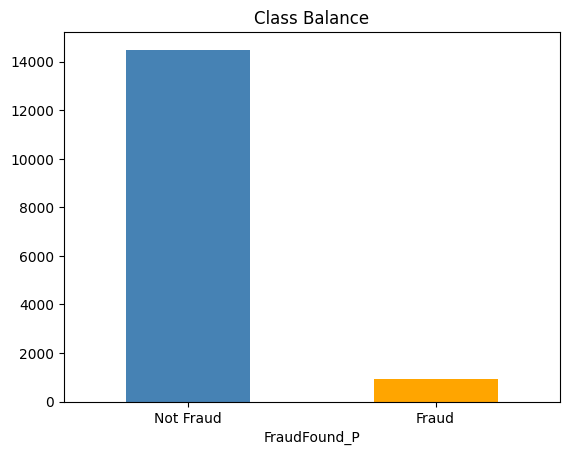

In [33]:
fig, ax = plt.subplots()
df[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, color=["steelblue", "orange"])
ax.set_xticklabels(["Not Fraud", "Fraud"], rotation=0)
ax.set_title("Class Balance")
plt.show()

## 3. Age distribution


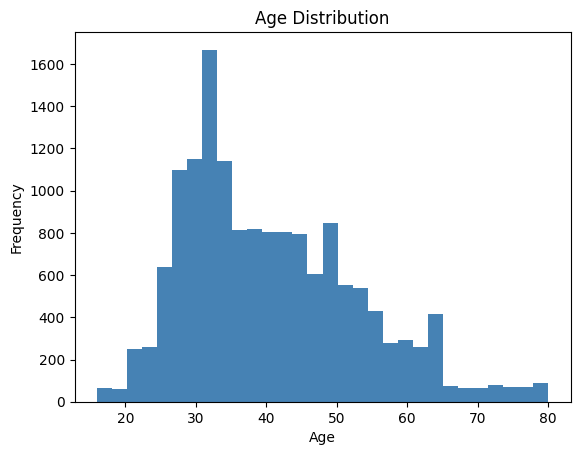

In [34]:
fig, ax = plt.subplots()
df["Age"].plot(kind="hist", bins=30, ax=ax, color="steelblue")
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
plt.show()

## 4. Fraud rate by vehicle category



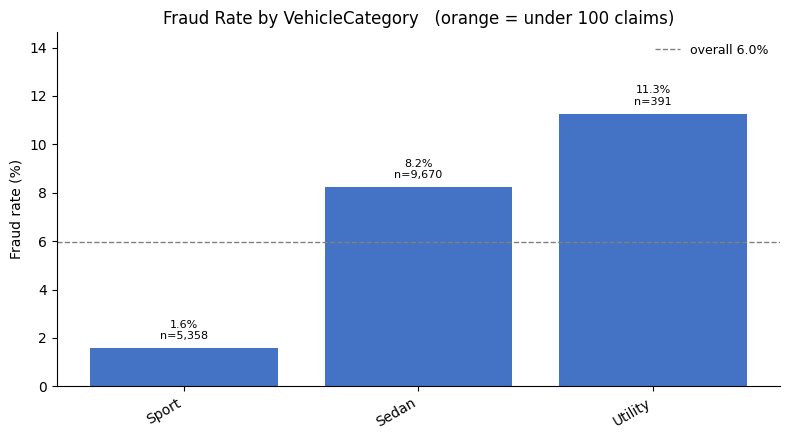

,claims,fraud,rate
VehicleCategory,,,
Sport,5358,84,1.567749
Sedan,9670,795,8.221303
Utility,391,44,11.253197


In [51]:
plot_fraud_rate("VehicleCategory")

## 5. Fraud rate by fault

Third-party-fault claims have a noticeably lower fraud rate than policyholder-fault claims. This is intuitive: it's harder to fake fault that isn't yours. We check whether `Fault` also carries weight in the baseline model's coefficients in Task 5.

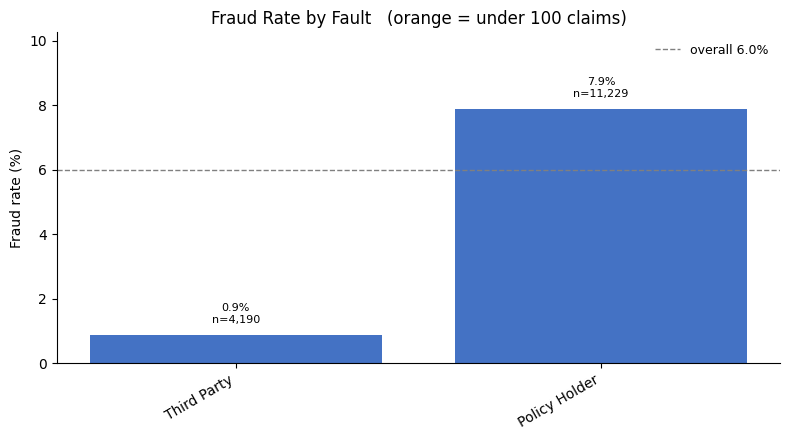

,claims,fraud,rate
Fault,,,
Third Party,4190,37,0.883055
Policy Holder,11229,886,7.890284


In [52]:
plot_fraud_rate("Fault")

## 6. Fraud rate by year (validating the temporal split)

The project requires a temporal hold-out split (train on earlier years, test on the most recent year) instead of random K-Fold, since the data spans 1994–1996. Before trusting that split, check that the fraud rate doesn't swing wildly year to year — a big jump would make training on the past and testing on 1996 unfair to the model.

Result: 6.7% → 5.8% → 5.2%, a gentle decline rather than a cliff, so the split is safe to use.

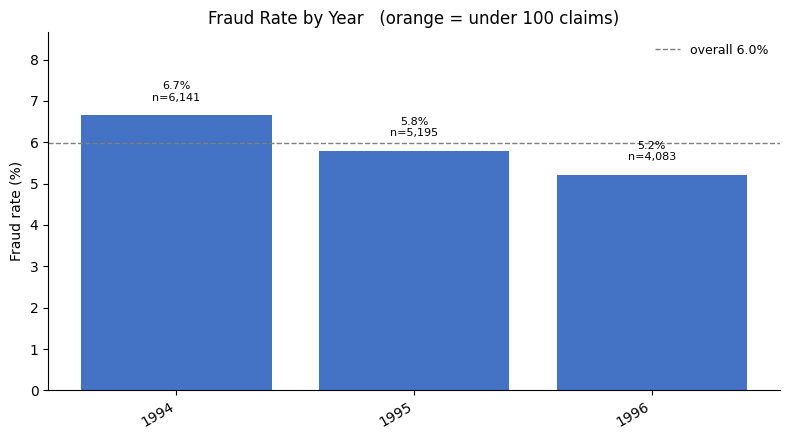

,claims,fraud,rate
Year,,,
1994,6141,409,6.660153
1995,5195,301,5.794033
1996,4083,213,5.216752


In [53]:
plot_fraud_rate("Year", sort=False)

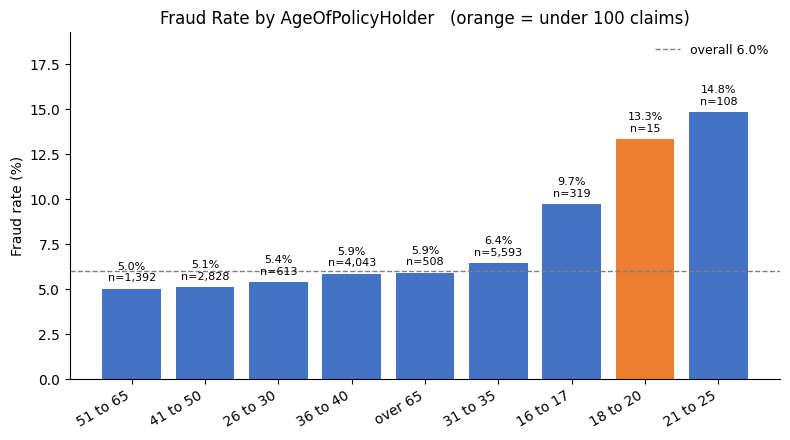

,claims,fraud,rate
AgeOfPolicyHolder,,,
51 to 65,1392,70,5.028736
41 to 50,2828,144,5.091938
26 to 30,613,33,5.383361
36 to 40,4043,237,5.861984
over 65,508,30,5.905512
31 to 35,5593,360,6.436617
16 to 17,319,31,9.717868
18 to 20,15,2,13.333333
21 to 25,108,16,14.814815


In [54]:
plot_fraud_rate("AgeOfPolicyHolder")

## 7. Fraud rate by policy type

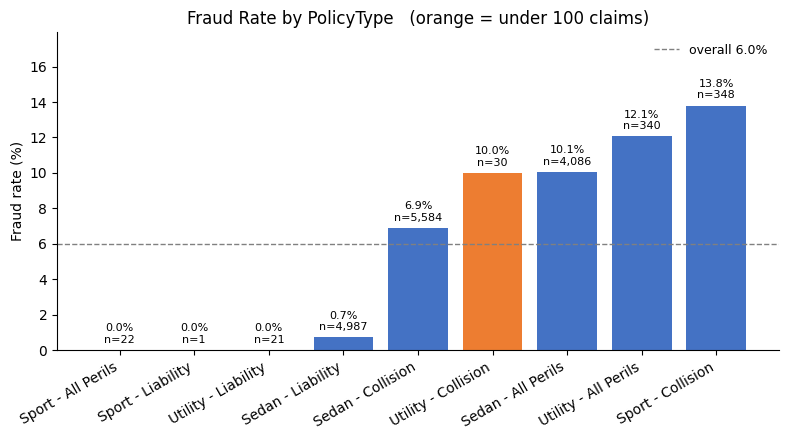

,claims,fraud,rate
PolicyType,,,
Sport - All Perils,22,0,0.000000
Sport - Liability,1,0,0.000000
Utility - Liability,21,0,0.000000
Sedan - Liability,4987,36,0.721877
Sedan - Collision,5584,384,6.876791
Utility - Collision,30,3,10.000000
Sedan - All Perils,4086,411,10.058737
Utility - All Perils,340,41,12.058824
Sport - Collision,348,48,13.793103


In [55]:
plot_fraud_rate("PolicyType")

## 8. Fraud rate by Accident Area

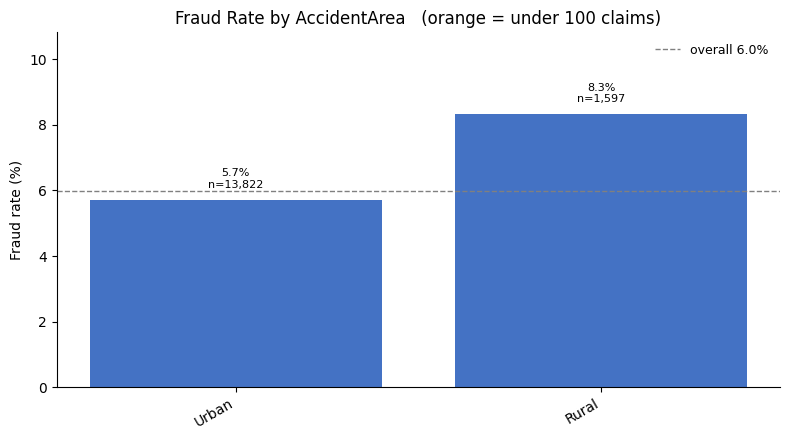

,claims,fraud,rate
AccidentArea,,,
Urban,13822,790,5.715526
Rural,1597,133,8.328115


In [56]:
plot_fraud_rate("AccidentArea")

## 9. Fraud rate by Sex

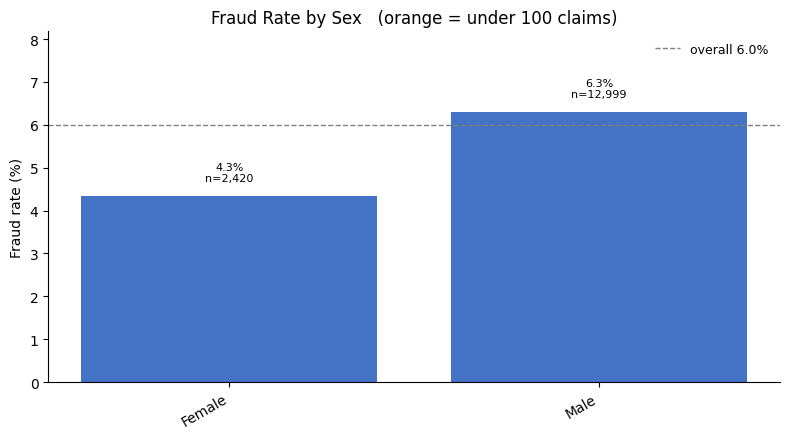

,claims,fraud,rate
Sex,,,
Female,2420,105,4.338843
Male,12999,818,6.292792


In [57]:
plot_fraud_rate("Sex")

**Sections 7–9 nots:**

**Policy Type:** fraud rate ranges from 0% to 13.8%, but four of the nine combinations have fewer than 350 claims and one (Sport - Liability) has a single claim, so the extremes are unreliable. The dependable split is Liability (0.7% across 4,987 Sedan claims) against Collision and All Perils (6.9% to 13.8%), which largely restates BasePolicy.

**Accident Area:** rural claims run 8.3% fraud (1,597 claims) against 5.7% urban (13,822 claims). Both groups are large enough to trust.

**Sex:** male policyholders show 6.3% (12,999 claims) against 4.3% female (2,420 claims). Sex is not a leakage risk, but using it in an insurance model raises fairness and regulatory questions. It is kept for the baseline and flagged for review before any production use.

The two highest bars, "18 to 20" (15 claims) and "21 to 25" (108 claims), rest on 18 fraud cases between them and should not be read as a finding. The reliable signal is that "16 to 17" (319 claims, 9.7%) runs above average, and those are the rows where Age was not recorded, which Age_missing already captures.

In [42]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             f1_score, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET = "FraudFound_P"

train = df[df["Year"] == 1994]
val   = df[df["Year"] == 1995]
test  = df[df["Year"] == 1996]

def make_model(X, class_weight=None):
    num = X.select_dtypes("number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    prep = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])
    return Pipeline([("prep", prep),
                     ("clf", LogisticRegression(max_iter=1000,
                                                class_weight=class_weight))])

def top_k(y_true, probs, frac):
    y_true = np.asarray(y_true)
    idx = np.argsort(probs)[::-1][:int(len(y_true) * frac)]
    hits = y_true[idx].sum()
    return hits / len(idx), hits / y_true.sum()

def evaluate(y_true, probs, preds):
    out = {
        "Precision (0.5 threshold)": precision_score(y_true, preds, zero_division=0),
        "Recall (0.5 threshold)":    recall_score(y_true, preds, zero_division=0),
        "F1 (0.5 threshold)":        f1_score(y_true, preds, zero_division=0),
        "PR-AUC": average_precision_score(y_true, probs),
    }
    for frac in (0.10, 0.20):
        p, c = top_k(y_true, probs, frac)
        out[f"Precision @ top {frac:.0%}"] = p
        out[f"Fraud caught @ top {frac:.0%}"] = c
    return out

In [43]:
# Task 3: Feature Leakage Audit
# Question: would we know this when the claim is first filed?
rows = [
    # Feature, Timing, Leakage risk, Decision, Reason
    ("Month",               "At filing", "No", "Keep", "Month of accident"),
    ("WeekOfMonth",         "At filing", "No", "Keep", "Week of accident"),
    ("DayOfWeek",           "At filing", "No", "Keep", "Day of accident"),
    ("MonthClaimed",        "At filing", "No", "Keep", "Recorded when the claim is filed"),
    ("WeekOfMonthClaimed",  "At filing", "No", "Keep", "Recorded when the claim is filed"),
    ("DayOfWeekClaimed",    "At filing", "No", "Keep", "Recorded when the claim is filed"),
    ("Make",                "At filing", "No", "Keep", "Vehicle attribute on the policy"),
    ("VehicleCategory",     "At filing", "No", "Keep", "Vehicle attribute on the policy"),
    ("VehiclePrice",        "At filing", "No", "Keep", "Vehicle attribute on the policy"),
    ("AgeOfVehicle",        "At filing", "No", "Keep", "Vehicle attribute on the policy"),
    ("NumberOfCars",        "At filing", "No", "Keep", "Policy attribute"),
    ("AccidentArea",        "At filing", "No", "Keep", "Reported by claimant"),
    ("Fault",               "At filing", "Low", "Keep", "Strong signal; confirm fault is reported at filing, not decided later"),
    ("Sex",                 "At filing", "No", "Keep (review)", "Not leakage; fairness review before production"),
    ("MaritalStatus",       "At filing", "No", "Keep", "Policyholder attribute"),
    ("Age",                 "At filing", "No", "Keep", "Policyholder attribute (0 treated as missing)"),
    ("Age_missing",         "At filing", "No", "Keep", "Flag for rows where Age was not recorded (Task 2)"),
    ("AgeOfPolicyHolder",   "At filing", "No", "Keep", "Binned age; overlaps with Age"),
    ("PolicyType",          "At filing", "No", "Keep", "Policy attribute"),
    ("BasePolicy",          "At filing", "No", "Keep", "Policy attribute"),
    ("Deductible",          "At filing", "No", "Keep", "Policy attribute"),
    ("DriverRating",        "At filing", "No", "Keep", "Policy attribute; confirm calculated before this claim"),
    ("AgentType",           "At filing", "No", "Keep", "Policy attribute"),
    ("Days_Policy_Accident","At filing", "No", "Keep", "Policy start to accident date"),
    ("Days_Policy_Claim",   "At filing", "No", "Keep", "Policy start to claim date"),
    ("PastNumberOfClaims",  "At filing", "Low", "Keep", "Prior history; confirm it excludes the current claim"),
    ("PoliceReportFiled",    "Unclear (no timestamps)", "Possible", "Drop",
         "Cannot confirm whether a report exists at first notice of loss; dropping costs little (see comparison below), so excluded as the safer choice"),
    ("WitnessPresent",       "Unclear (no timestamps)", "Possible", "Drop",
         "Cannot confirm whether witnesses are recorded at intake or found during investigation; dropping costs little, so excluded as the safer choice"),
    ("AddressChange_Claim",  "Unclear (no timestamps)", "Possible", "Drop",
         "Cannot confirm whether this reflects history at submission or is updated during handling; dropping costs little, so excluded as the safer choice"),
    ("NumberOfSuppliments", "Later in claim lifecycle", "Yes", "Drop",
        "Supplements are added as the claim is processed"),
    ("PolicyNumber",        "At filing", "No", "Drop", "Identifier; also encodes time (corr with Year ~0.94)"),
    ("RepNumber",           "At filing", "No", "Drop", "Identifier; may reflect operational assignment"),
    ("Year",                "At filing", "No", "Drop as feature", "Used for the temporal split only"),
]
audit = pd.DataFrame(rows, columns=["Feature", "Timing", "Leakage Risk", "Decision", "Reason"])

# Guard: every column except the target must be audited
unaudited = set(df.columns) - {TARGET} - set(audit["Feature"])
assert not unaudited, f"Not audited: {unaudited}"
pd.set_option("display.max_colwidth", None)
display(audit)

SAFE_FEATURES = audit.loc[~audit["Decision"].str.startswith("Drop"), "Feature"].tolist()
DROP_COLS     = audit.loc[audit["Decision"].str.startswith("Drop"), "Feature"].tolist()
DROPPED_PENDING = ["PoliceReportFiled", "WitnessPresent", "AddressChange_Claim"]
print(f"Final safe feature set ({len(SAFE_FEATURES)}):", SAFE_FEATURES)
print("Dropped:", DROP_COLS)

# Evidence: how much do the dropped features change results?
comparison = {}
for name, feats in {
    "Final set (26 features)":       SAFE_FEATURES,
    "Final + the 3 timing-unclear":  SAFE_FEATURES + DROPPED_PENDING,
    "Final + NumberOfSuppliments":   SAFE_FEATURES + ["NumberOfSuppliments"],
}.items():
    X_tr, X_va = train[feats].copy(), val[feats].copy()
    for X in (X_tr, X_va):
        if "Age_missing" in X:
            X["Age_missing"] = X["Age_missing"].astype(int)
    m = make_model(X_tr).fit(X_tr, train[TARGET])
    comparison[name] = evaluate(val[TARGET], m.predict_proba(X_va)[:, 1], m.predict(X_va))

display(pd.DataFrame(comparison).T[["PR-AUC", "Fraud caught @ top 10%",
                                    "Fraud caught @ top 20%"]].round(3))

,Feature,Timing,Leakage Risk,Decision,Reason
0,Month,At filing,No,Keep,Month of accident
1,WeekOfMonth,At filing,No,Keep,Week of accident
2,DayOfWeek,At filing,No,Keep,Day of accident
3,MonthClaimed,At filing,No,Keep,Recorded when the claim is filed
4,WeekOfMonthClaimed,At filing,No,Keep,Recorded when the claim is filed
5,DayOfWeekClaimed,At filing,No,Keep,Recorded when the claim is filed
6,Make,At filing,No,Keep,Vehicle attribute on the policy
7,VehicleCategory,At filing,No,Keep,Vehicle attribute on the policy
8,VehiclePrice,At filing,No,Keep,Vehicle attribute on the policy
9,AgeOfVehicle,At filing,No,Keep,Vehicle attribute on the policy


Final safe feature set (26): ['Month', 'WeekOfMonth', 'DayOfWeek', 'MonthClaimed', 'WeekOfMonthClaimed', 'DayOfWeekClaimed', 'Make', 'VehicleCategory', 'VehiclePrice', 'AgeOfVehicle', 'NumberOfCars', 'AccidentArea', 'Fault', 'Sex', 'MaritalStatus', 'Age', 'Age_missing', 'AgeOfPolicyHolder', 'PolicyType', 'BasePolicy', 'Deductible', 'DriverRating', 'AgentType', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims']
Dropped: ['PoliceReportFiled', 'WitnessPresent', 'AddressChange_Claim', 'NumberOfSuppliments', 'PolicyNumber', 'RepNumber', 'Year']


,PR-AUC,Fraud caught @ top 10%,Fraud caught @ top 20%
Final set (26 features),0.100,0.176,0.349
Final + the 3 timing-unclear,0.101,0.169,0.359
Final + NumberOfSuppliments,0.100,0.173,0.346


**Audit conclusion.** All 33 feature columns plus the target were reviewed. Seven are excluded: PolicyNumber (encodes year, correlation 0.94), RepNumber (operational identifier), NumberOfSuppliments (accumulates after filing), Year (used for the split only), and PoliceReportFiled, WitnessPresent and AddressChange_Claim (timing cannot be confirmed). The comparison above measures what the three timing-unclear columns are worth on the validation year: the difference is small either way, so excluding them is close to free and removes the risk. Final feature set: 26 columns.

In [44]:
# Task 5: Baseline Logistic Regression
# Chronological split: train 1994, validate 1995, test 1996 (opened once)

X_train, y_train = train[SAFE_FEATURES], train[TARGET]
X_val,   y_val   = val[SAFE_FEATURES],   val[TARGET]
X_test,  y_test  = test[SAFE_FEATURES],  test[TARGET]

candidates = {"Baseline LogReg": None, "Balanced LogReg": "balanced"}

val_scores = {}
for name, cw in candidates.items():
    m = make_model(X_train, class_weight=cw).fit(X_train, y_train)
    val_scores[name] = evaluate(y_val, m.predict_proba(X_val)[:, 1], m.predict(X_val))

print("Validation (1995), used to choose the model:")
display(pd.DataFrame(val_scores).round(3))

Validation (1995), used to choose the model:


,Baseline LogReg,Balanced LogReg
Precision (0.5 threshold),0.056,0.102
Recall (0.5 threshold),0.003,0.439
F1 (0.5 threshold),0.006,0.166
PR-AUC,0.100,0.097
Precision @ top 10%,0.102,0.114
Fraud caught @ top 10%,0.176,0.196
Precision @ top 20%,0.101,0.097
Fraud caught @ top 20%,0.349,0.336


In [45]:
# Refit the winner on 1994+1995, then score ONCE on 1996
WINNER_NAME   = "Baseline LogReg"   # change after reading the validation table
WINNER_WEIGHT = None                # None for Baseline, "balanced" for Balanced

trainval = df[df["Year"] <= 1995]
X_tv, y_tv = trainval[SAFE_FEATURES], trainval[TARGET]

final = make_model(X_tv, class_weight=WINNER_WEIGHT).fit(X_tv, y_tv)
probs = final.predict_proba(X_test)[:, 1]
preds = final.predict(X_test)

base_rate = y_test.mean()
final_table = {
    WINNER_NAME: evaluate(y_test, probs, preds),
    "Random guess": {
        "Precision (0.5 threshold)": np.nan,
        "Recall (0.5 threshold)": np.nan,
        "F1 (0.5 threshold)": np.nan,
        "PR-AUC": base_rate,
        "Precision @ top 10%": base_rate,
        "Fraud caught @ top 10%": 0.10,
        "Precision @ top 20%": base_rate,
        "Fraud caught @ top 20%": 0.20,
    },
}
print("Test (1996), final evaluation, opened once:")
display(pd.DataFrame(final_table).round(3))
print(classification_report(y_test, preds, digits=3, zero_division=0))

Test (1996), final evaluation, opened once:


,Baseline LogReg,Random guess
Precision (0.5 threshold),0.000,NaN
Recall (0.5 threshold),0.000,NaN
F1 (0.5 threshold),0.000,NaN
PR-AUC,0.095,0.052
Precision @ top 10%,0.083,0.052
Fraud caught @ top 10%,0.160,0.100
Precision @ top 20%,0.091,0.052
Fraud caught @ top 20%,0.347,0.200


              precision    recall  f1-score   support

           0      0.948     1.000     0.973      3870
           1      0.000     0.000     0.000       213

    accuracy                          0.948      4083
   macro avg      0.474     0.500     0.487      4083
weighted avg      0.898     0.948     0.922      4083



In [46]:
# Top drivers in the balanced baseline
m = final
coefs = pd.Series(m.named_steps["clf"].coef_[0],
                  index=m.named_steps["prep"].get_feature_names_out()).sort_values()
print("Pushes toward NOT fraud:"); display(coefs.head(10).round(3))
print("Pushes toward fraud:");     display(coefs.tail(10).round(3))

Pushes toward NOT fraud:


,0
cat__Fault_Third Party,-1.576
cat__BasePolicy_Liability,-1.177
cat__PolicyType_Sedan - Liability,-0.925
cat__Make_VW,-0.844
cat__AgentType_Internal,-0.807
cat__Days_Policy_Claim_more than 30,-0.712
cat__Make_Dodge,-0.578
cat__Days_Policy_Accident_8 to 15,-0.539
cat__AgeOfVehicle_new,-0.537
cat__MonthClaimed_Nov,-0.535


Pushes toward fraud:


,0
cat__Month_Feb,0.281
cat__AgeOfPolicyHolder_21 to 25,0.345
cat__Month_Mar,0.359
cat__BasePolicy_Collision,0.410
cat__Days_Policy_Claim_8 to 15,0.492
cat__PolicyType_Sedan - All Perils,0.502
cat__AgeOfVehicle_4 years,0.529
cat__Make_Acura,0.539
cat__PolicyType_Sport - Collision,0.897
cat__Fault_Policy Holder,0.964


In [47]:
print(df.shape)
print(train.shape, test.shape)

(15419, 34)
(6141, 34) (4083, 34)


In [48]:
#draft check
# Choose an operating threshold on VALIDATION, then apply it to test
CAPACITY = 0.20   # investigators review the top 20% of scored claims

val_model  = make_model(X_train).fit(X_train, y_train)
val_probs  = val_model.predict_proba(X_val)[:, 1]
threshold  = np.quantile(val_probs, 1 - CAPACITY)
print(f"Threshold from 1995 at {CAPACITY:.0%} capacity: {threshold:.4f}")

# Apply that same threshold to 1996
preds_cap = (probs >= threshold).astype(int)
print(f"\nShare of 1996 claims flagged: {preds_cap.mean():.1%}")
print(classification_report(y_test, preds_cap, digits=3, zero_division=0))


Threshold from 1995 at 20% capacity: 0.0964

Share of 1996 claims flagged: 24.3%
              precision    recall  f1-score   support

           0      0.961     0.767     0.853      3870
           1      0.093     0.432     0.153       213

    accuracy                          0.750      4083
   macro avg      0.527     0.600     0.503      4083
weighted avg      0.916     0.750     0.817      4083



In [58]:
# Export results for the milestone submission
val_df  = pd.DataFrame(val_scores).round(4)
test_df = pd.DataFrame(final_table).round(4)

val_df.columns  = [f"{c} (validation 1995)" for c in val_df.columns]
test_df.columns = [f"{c} (test 1996)" for c in test_df.columns]

summary = pd.concat([val_df, test_df], axis=1)
summary.to_csv("september_baseline_results.csv")
print("Saved september_baseline_results.csv")
display(summary)

Saved september_baseline_results.csv


,Baseline LogReg (validation 1995),Balanced LogReg (validation 1995),Baseline LogReg (test 1996),Random guess (test 1996)
Precision (0.5 threshold),0.0556,0.1024,0.0000,NaN
Recall (0.5 threshold),0.0033,0.4385,0.0000,NaN
F1 (0.5 threshold),0.0063,0.1660,0.0000,NaN
PR-AUC,0.1002,0.0973,0.0947,0.0522
Precision @ top 10%,0.1021,0.1137,0.0833,0.0522
Fraud caught @ top 10%,0.1761,0.1960,0.1596,0.1000
Precision @ top 20%,0.1011,0.0972,0.0907,0.0522
Fraud caught @ top 20%,0.3488,0.3355,0.3474,0.2000


In [59]:
summary.loc["Precision (top 20% threshold)", f"{WINNER_NAME} (test 1996)"] = precision_score(y_test, preds_cap, zero_division=0)
summary.loc["Recall (top 20% threshold)",    f"{WINNER_NAME} (test 1996)"] = recall_score(y_test, preds_cap, zero_division=0)
summary.loc["F1 (top 20% threshold)",        f"{WINNER_NAME} (test 1996)"] = f1_score(y_test, preds_cap, zero_division=0)
summary.round(4).to_csv("september_baseline_results.csv")

## Summary of Tasks 4 and 5

**Data:** 15,419 claims from 1994 to 1996, 923 fraud (5.99%). The only missing values are 319 Age entries, recorded as 0 in the raw file and treated as missing in Task 2, marked by `Age_missing`. Because fraud is this rare, accuracy is not a usable metric: always answering "not fraud" scores 94% while catching nothing.

### Task 4: what the EDA found

Every fraud rate chart shows the claim count beside the rate, and groups under 100 claims are highlighted, because small groups swing wildly on a handful of cases.

**Holds up** (large groups, clear separation):

| Feature | Higher risk | Lower risk |
|---|---|---|
| Fault | Policy Holder, 7.9% (11,229 claims) | Third Party, 0.9% (4,190) |
| Vehicle category | Sedan, 8.2% (9,670) | Sport, 1.6% (5,358) |
| Accident area | Rural, 8.3% (1,597) | Urban, 5.7% (13,822) |
| Sex | Male, 6.3% (12,999) | Female, 4.3% (2,420) |

Fault is the strongest single signal, and the gap has a plain explanation that is not leakage: when a third party is at fault their insurer pays, so there is far less incentive to fake a claim on your own policy.

**Does not hold up:**
- **Age of policyholder.** The two tallest bars are "18 to 20" (15 claims) and "21 to 25" (108 claims), 18 fraud cases between them. Without the counts this looks like the biggest finding in the data. The reliable part is "16 to 17" (319 claims, 9.7%), which is exactly the rows where Age was never recorded, already captured by `Age_missing`.
- **Policy type.** Four of nine combinations have under 350 claims and one (Sport - Liability) has a single claim. The three categories at 0.0% fraud sit on 22, 1 and 21 claims, so those zeros mean nothing. The dependable pattern is Liability (0.7%) against Collision and All Perils (6.9% to 13.8%), which mostly restates BasePolicy.
- **Utility vehicles** show the highest category rate at 11.3%, but on only 391 claims.

**Fraud rate by year:** 6.7% (1994), 5.8% (1995), 5.2% (1996). A gradual decline rather than a cliff, which is what makes a chronological split fair.

`Sex` is not a leakage risk but raises fairness and regulatory questions. Kept for the baseline, flagged for review before production.

### Leakage audit conclusion

**Final feature set: 26 columns.** Seven excluded:

- **PolicyNumber** runs in order by year (1994 is 1 to 6142, and so on), so it encodes time.
- **RepNumber** is an operational identifier. Fraud rates are flat across all 16 reps.
- **NumberOfSuppliments** accumulates after the claim is filed.
- **PoliceReportFiled, WitnessPresent, AddressChange_Claim**: timing cannot be confirmed without the host company.
- **Year** builds the split and is never shown to the model.

The three timing-unclear columns were measured rather than argued about. On validation, including them is worth 0.001 PR-AUC and the capture rates move in opposite directions. Since excluding them costs almost nothing and keeping a leaky column means a quietly invalid model, they are excluded.

### Task 5: the baseline model

**Split:** train 1994 (6,141 claims, 409 fraud), validate 1995 (5,195 / 301), test 1996 (4,083 / 213). All preprocessing sits inside a Pipeline so it is fit on training data only. The final model is refit on 1994 and 1995 before scoring 1996, which is opened once.

**Model choice.** Baseline and Balanced logistic regression were compared on 1995 only. Baseline won PR-AUC (0.100 vs 0.097) and both top-20% metrics, Balanced won the top-10% metrics. Baseline was chosen, but this was a near tie and worth revisiting if the review capacity lands at 10%.

**Final results on 1996:**

| Metric | Model | Random guess |
|---|---|---|
| PR-AUC | 0.095 | 0.052 |
| Fraud caught, top 10% | 0.160 | 0.100 |
| Fraud caught, top 20% | **0.347** | 0.200 |

Reviewing the top 20% of scored claims catches 34.7% of fraud against 20% at random, roughly a 1.7x lift.

**Operating threshold.** At the default 0.5 cutoff the model flags nothing, so precision, recall and F1 all read zero. That is expected for an unweighted model at 95% negatives, not a failure. A threshold was instead set on 1995 to match a 20% review capacity (0.0964) and applied unchanged to 1996:

| Metric (fraud class) | Model | Random at same capacity |
|---|---|---|
| Precision | 0.093 | 0.052 |
| Recall | 0.432 | 0.243 |
| F1 | 0.153 | n/a |

**This is also a drift finding.** The threshold was set to flag 20% and flagged 24.3%, so the model scores 1996 claims as riskier than 1995 even though the real fraud rate fell. A deployed version should recalibrate periodically or use a capacity rule rather than a fixed cutoff.

**What drives the score.** Largest coefficients are Fault (Policy Holder +0.96, Third Party -1.58), BasePolicy Liability (-1.18), PolicyType Sedan - Liability (-0.93) and Sport - Collision (+0.90). All are policy-level characteristics available the moment a claim is filed. Nothing in the top ten depends on an investigation having happened.

### Limitations

- PR-AUC of 0.095 beats random but is a September baseline, not production quality.
- No confidence intervals yet. With only 213 fraud cases in the test year, a single metric is noisy. Bootstrapping is the October fix.
- Three columns are excluded on an unconfirmed assumption. If the host company confirms they are recorded at intake, they can be added back for about 0.001 PR-AUC.
- Age and AgeOfPolicyHolder disagree on roughly 45% of rows and both are in the feature set. One should be picked deliberately.
- PolicyType overlaps with VehicleCategory and BasePolicy, and all three are in the model.
- Sex needs a fairness review before any production use.

**Leakage Audit Conclusion**
- **Dropped:** NumberOfSuppliments (accumulates after filing), PolicyNumber and RepNumber (identifiers; PolicyNumber also encodes time).
- **Split only:** Year. **Target:** FraudFound_P.
- **Kept, pending advisor confirmation:** PoliceReportFiled, WitnessPresent, AddressChange_Claim. The dataset has no timestamps, so timing is assumed from field definitions.
- **Final feature set:** 29 columns.
- The comparison table shows how much the pending features change results. If the advisor says they are recorded after filing, we drop them and rerun.

**Official September baseline:** the "Baseline LogReg" column. "Balanced LogReg (October preview)" uses class weighting and is shown only for comparison. "Random guess" is the reference line.

- We built a simple logistic regression trained on 1994-1995 claims and tested on 1996 claims.
- PR-AUC is [your PR-AUC] (random guessing is about 0.05).
- Reviewing the top 10% of claims catches [your top 10%] of fraud, and the top 20% catches [your top 20%].

Three kept features may be recorded after the claim is filed, which could inflate results.
